# Joint Block-Diagonal Masked TCA Pipeline

Fits a single nonnegative TCA (`ncp_hals`) on a block-diagonal tensor combining
data from multiple sessions. Each session contributes its own neuron and trial
blocks; sessions are linked through a **shared time axis**. A binary mask ensures
only observed (diagonal-block) entries drive the decomposition.

**Per-session:** SVD spikes → neurons×time×trials tensor → speed correction → optional z-score → nonneg shift.
**Joint:** Stack neurons and trials; construct diagonal-block mask.
**TCA:** `ncp_hals` with mask, rank sweep, best-replicate selection via elbow.

In [1]:
from pathlib import Path
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mpl_ticker
import seaborn as sns
import pickle

import scipy
if not hasattr(scipy, "random"):
    import numpy.random
    scipy.random = numpy.random
import tensortools as tt

base = Path.cwd()
for p in [base, *base.parents]:
    if (p / "data").exists():
        project_root = p
        break
else:
    project_root = base

data_root = str(project_root / "data")
results_dir = project_root / "results" / "joint_tca"
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Data root: {data_root}")
print(f"Results dir: {results_dir}")

Data root: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data
Results dir: /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/joint_tca


## Configuration

In [2]:
# ── Choose which sessions to combine in the joint tensor ──
# Pick any subset of keys from SESSION_REGISTRY below.
# Examples:
#   ["sup_bef", "unsup_bef"]   → cross-cohort, before learning
#   ["sup_aft", "unsup_aft"]   → cross-cohort, after learning
#   ["sup_bef", "sup_aft"]     → same mouse (supervised), before vs after
#   ["unsup_bef", "unsup_aft"] → same mouse (unsupervised), before vs after
SESSIONS_TO_USE = ["unsup_bef", "unsup_aft"]

SESSION_REGISTRY = {
    "sup_bef": {
        "target": "VR2_2021_03_20_1",
        "beh_file": "Beh_sup_train1_before_learning.npy",
        "cohort": "supervised",
        "timepoint": "before",
    },
    "sup_aft": {
        "target": "VR2_2021_04_06_1",
        "beh_file": "Beh_sup_train1_after_learning.npy",
        "cohort": "supervised",
        "timepoint": "after",
    },
    "unsup_bef": {
        "target": "TX105_2022_10_08_2",
        "beh_file": "Beh_unsup_train1_before_learning.npy",
        "cohort": "unsupervised",
        "timepoint": "before",
    },
    "unsup_aft": {
        "target": "TX105_2022_10_19_2",
        "beh_file": "Beh_unsup_train1_after_learning.npy",
        "cohort": "unsupervised",
        "timepoint": "after",
    },
}

for _k in SESSIONS_TO_USE:
    if _k not in SESSION_REGISTRY:
        raise ValueError(f"Unknown session key: {_k!r}. Choose from {list(SESSION_REGISTRY)}")
SESSIONS = {k: SESSION_REGISTRY[k] for k in SESSIONS_TO_USE}
print(f"Sessions to combine: {list(SESSIONS.keys())}")

BUFFER_TUNNEL = (2, 8)
ALIGNMENT = "Trial_start_time"

RANK_RANGE = range(1, 4)   # ranks 1-3 for feasibility testing
REPLICATES = 2

# "residuals" (speed-corrected) or "zscored" (per-neuron robust z-score of residuals)
TCA_INPUT = "zscored"

AREA_PALETTE = {
    "V1": "#1f77b4", "mHV": "#2ca02c", "lHV": "#d62728",
    "aHV": "#9467bd", "Other": "#7f7f7f",
}

# Trial scatter colors: saturated for supervised, lighter for unsupervised.
# Only the keys matching the current SESSIONS will be used.
SESSION_STIM_PALETTE = {
    "sup_bef / leaf1":   "#02968a", "sup_bef / circle1":   "#DFAE32",
    "sup_aft / leaf1":   "#015c55", "sup_aft / circle1":   "#b08a1e",
    "unsup_bef / leaf1": "#80CBC4", "unsup_bef / circle1": "#FFE082",
    "unsup_aft / leaf1": "#4DB6AC", "unsup_aft / circle1": "#FFD54F",
}

BLOCK_SHADE = {
    "sup_bef": "#BBDEFB", "sup_aft": "#90CAF9",
    "unsup_bef": "#FFE0B2", "unsup_aft": "#FFCC80",
}

Sessions to combine: ['unsup_bef', 'unsup_aft']


In [3]:
def load_neuron_to_area(root, recording_name):
    filename = os.path.join(root, recording_name[:-1] + "trans.npz")
    with np.load(filename, allow_pickle=True) as f:
        df = pd.DataFrame({"iarea": f["iarea"]})
    df["neuron"] = df.index.astype(int)
    area_map = pd.Series({
        8: "V1", 0: "mHV", 1: "mHV", 2: "mHV", 9: "mHV",
        5: "lHV", 6: "lHV", 3: "aHV", 4: "aHV",
    })
    df["area"] = df["iarea"].map(area_map).fillna("Other")
    return df.set_index("neuron")["area"]


def create_3d_matrix(trial_timestamps, buffer, spiking_data, spiking_timestamps):
    n_trials = len(trial_timestamps)
    n_time = buffer[0] + buffer[1] + 1
    n_neurons = spiking_data.shape[1]
    tensor = np.zeros((n_neurons, n_time, n_trials), dtype=np.float32)
    for i, ts in enumerate(trial_timestamps):
        idx = np.searchsorted(spiking_timestamps, ts, side="right")
        tensor[:, :, i] = spiking_data[idx - buffer[0] : idx + buffer[1] + 1, :].T
    return tensor


def create_speed_matrix(trial_timestamps, buffer, spiking_timestamps, run_speed):
    n_time = buffer[0] + buffer[1] + 1
    idx = np.searchsorted(spiking_timestamps, trial_timestamps, side="right")
    return run_speed[np.arange(n_time)[:, None] + (idx - buffer[0])].astype(np.float32)


def speed_correct_tensor(tensor, speed_matrix, correct_by="simple"):
    n_neurons, n_time, n_trials = tensor.shape
    n_obs = n_time * n_trials
    ones = np.ones((n_obs, 1), dtype=np.float64)
    speed = speed_matrix.ravel().reshape(-1, 1)
    if correct_by == "simple":
        X = np.hstack([ones, speed])
    elif correct_by == "bytrial":
        trial_idx = np.repeat(np.arange(n_trials), n_time)
        X = np.hstack([ones, speed,
                       (trial_idx[:, None] == np.arange(1, n_trials)).astype(np.float64)])
    else:
        raise ValueError(f"Unknown correct_by: {correct_by}")
    Y = tensor.reshape(n_neurons, n_obs).T
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    return (Y - X @ B).T.reshape(n_neurons, n_time, n_trials).astype(np.float32)


def zscore_tensor(tensor):
    flat = tensor.reshape(tensor.shape[0], -1)
    med = np.median(flat, axis=1, keepdims=True)
    mad = 1.4826 * np.median(np.abs(flat - med), axis=1, keepdims=True)
    mad = np.where(mad > 1e-12, mad, 1e-12)
    return ((flat - med) / mad).reshape(tensor.shape).astype(np.float32)


def shift_nonneg(tensor):
    return tensor - tensor.min(axis=(1, 2), keepdims=True)


def canonical_factors(U, V, W, n0, n1, n2):
    if U.shape[0] == n0 and V.shape[0] == n1 and W.shape[0] == n2:
        return U, V, W
    if U.shape[1] == n0 and V.shape[1] == n1 and W.shape[1] == n2:
        return U.T, V.T, W.T
    raise ValueError(
        f"Factor shapes {[a.shape for a in (U, V, W)]} vs tensor ({n0}, {n1}, {n2})"
    )

## Load and preprocess each session

In [4]:
session_results = []

for label, info in SESSIONS.items():
    target = info["target"]
    spike_path = os.path.join(data_root, target + "_SVD_dec.npy")
    beh_path = os.path.join(data_root, info["beh_file"])

    svd = np.load(spike_path, allow_pickle=True).item()
    spikes = (svd["U"].T @ svd["V"]).T
    beh_all = np.load(beh_path, allow_pickle=True).item()
    beh = beh_all[target]
    ft = beh["ft"][:spikes.shape[0] + 1]
    run_speed = beh["ft_RunSpeed"][:len(ft)]
    neuron_to_area = load_neuron_to_area(data_root, target)
    assert len(neuron_to_area) == spikes.shape[1]

    trial_ts = beh[ALIGNMENT]
    tensor_raw = create_3d_matrix(trial_ts, BUFFER_TUNNEL, spikes, ft)
    speed_mat = create_speed_matrix(trial_ts, BUFFER_TUNNEL, ft, run_speed)
    tensor_corr = speed_correct_tensor(tensor_raw, speed_mat, correct_by="simple")

    tensor_input = zscore_tensor(tensor_corr) if TCA_INPUT == "zscored" else tensor_corr
    tensor_shifted = shift_nonneg(tensor_input)

    n_neurons, n_time_s, n_trials = tensor_shifted.shape
    trial_order = np.asarray(beh["trInd"][:n_trials], dtype=int)
    trial_stim = [str(s) for s in beh["TrialStim"][:n_trials]]

    print(f"{label} ({target}): {n_neurons} neurons x {n_time_s} time x {n_trials} trials  "
          f"range [{tensor_shifted.min():.4f}, {tensor_shifted.max():.4f}]")

    session_results.append({
        "label": label, "target": target,
        "cohort": info["cohort"], "timepoint": info["timepoint"],
        "tensor": tensor_shifted,
        "n_neurons": n_neurons, "n_trials": n_trials,
        "trial_order": trial_order, "trial_stim": trial_stim,
        "neuron_to_area": neuron_to_area,
    })

n_time = BUFFER_TUNNEL[0] + BUFFER_TUNNEL[1] + 1

unsup_bef (TX105_2022_10_08_2): 58941 neurons x 11 time x 201 trials  range [0.0000, 92.9922]
unsup_aft (TX105_2022_10_19_2): 55653 neurons x 11 time x 259 trials  range [0.0000, 171.7815]


## Construct block-diagonal tensor and mask

Each session occupies one diagonal block. The mask is `True` only inside these
blocks; `ncp_hals` imputes the off-diagonal (masked) entries during fitting.
The **time axis is shared** across all blocks, forcing the temporal factor V to
capture dynamics common to every session.

In [5]:
N_total = sum(s["n_neurons"] for s in session_results)
K_total = sum(s["n_trials"] for s in session_results)

stacked = np.zeros((N_total, n_time, K_total), dtype=np.float32)
mask = np.zeros((N_total, n_time, K_total), dtype=bool)

n_off, k_off = 0, 0
block_info = []
for s in session_results:
    nn, nk = s["n_neurons"], s["n_trials"]
    stacked[n_off:n_off + nn, :, k_off:k_off + nk] = s["tensor"]
    mask[n_off:n_off + nn, :, k_off:k_off + nk] = True
    block_info.append({
        "label": s["label"],
        "neuron_slice": (n_off, n_off + nn),
        "trial_slice": (k_off, k_off + nk),
    })
    n_off += nn
    k_off += nk

print(f"Stacked tensor: {stacked.shape}  ({stacked.nbytes / 1e9:.2f} GB)")
print(f"Mask observed: {mask.sum() / mask.size:.1%}")
for bi in block_info:
    print(f"  {bi['label']}: neurons [{bi['neuron_slice'][0]}:{bi['neuron_slice'][1]}), "
          f"trials [{bi['trial_slice'][0]}:{bi['trial_slice'][1]})")

Stacked tensor: (114594, 11, 460)  (2.32 GB)
Mask observed: 49.8%
  unsup_bef: neurons [0:58941), trials [0:201)
  unsup_aft: neurons [58941:114594), trials [201:460)


## Fit nonnegative TCA with mask

In [6]:
t_start = time.time()
ensemble = tt.Ensemble(fit_method="ncp_hals", fit_options={"mask": mask})
ensemble.fit(stacked, ranks=RANK_RANGE, replicates=REPLICATES)
print(f"\nFitting complete in {time.time() - t_start:.1f}s")

Fitting rank-1 models:   0%|          | 0/2 [00:00<?, ?it/s]/Users/johnmadrid/miniconda3/envs/isp-unsupervised-learning/lib/python3.9/site-packages/tensortools/optimize/ncp_hals.py:185: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  Cp = factors[:, idx] @ grams[idx][:, p]
                                                                    

Rank-1 models:  min obj, 0.23;  max obj, 0.23;  time to fit, 135.5s


Rank-2 models:  min obj, 0.22;  max obj, 0.22;  time to fit, 435.2s


Rank-3 models:  min obj, 0.22;  max obj, 0.22;  time to fit, 671.2s

Fitting complete in 1247.2s


Mean errors: {np.int64(1): np.float64(0.3061), np.int64(2): np.float64(0.3003), np.int64(3): np.float64(0.293)}
Best rank (elbow): 2


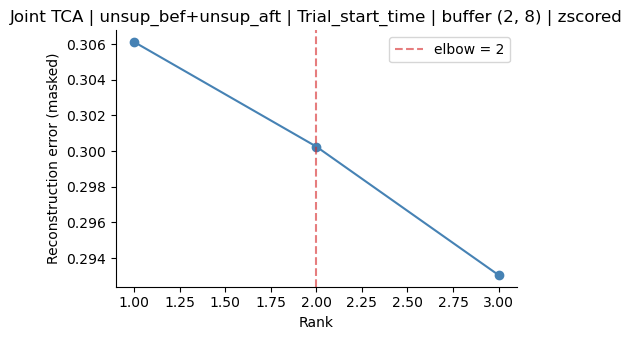

Saved: joint_tca_unsup_bef+unsup_aft_Trial_start_time_buf2-8_elbow_zscored.png


In [7]:
orig_norm = np.sqrt(sum(np.sum(s["tensor"] ** 2) for s in session_results))
mean_errors = []
best_rep_idx = {}

for r in RANK_RANGE:
    reps = ensemble.factors(r)
    best_idx, best_err = 0, None
    errs = []
    for i, facs in enumerate(reps):
        U, V, W = canonical_factors(*facs, N_total, n_time, K_total)
        sq_err = 0.0
        for bi, sr in zip(block_info, session_results):
            n0, n1 = bi["neuron_slice"]
            t0, t1 = bi["trial_slice"]
            Xhat_blk = np.einsum("ir,jr,kr->ijk", U[n0:n1], V, W[t0:t1])
            sq_err += np.sum((sr["tensor"] - Xhat_blk) ** 2)
        err = np.sqrt(sq_err) / (orig_norm + 1e-12)
        errs.append(err)
        if best_err is None or err < best_err:
            best_err, best_idx = err, i
    mean_errors.append(float(np.mean(errs)))
    best_rep_idx[int(r)] = int(best_idx)

x = np.arange(len(mean_errors), dtype=float) + 1.0
y = np.array(mean_errors)
m = (y[-1] - y[0]) / (x[-1] - x[0] + 1e-12)
b_line = y[0] - m * x[0]
dist = np.abs(m * x + b_line - y) / (np.sqrt(m**2 + 1) + 1e-12)
best_rank = int(max(1, x[np.argmax(dist)]))

print(f"Mean errors: {dict(zip(x.astype(int), np.round(y, 4)))}")
print(f"Best rank (elbow): {best_rank}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, y, "o-", color="steelblue")
ax.axvline(best_rank, color="tab:red", ls="--", alpha=0.6, label=f"elbow = {best_rank}")
ax.set_xlabel("Rank")
ax.set_ylabel("Reconstruction error (masked)")
session_str = "+".join(s["label"] for s in session_results)
ax.set_title(
    f"Joint TCA | {session_str} | {ALIGNMENT} | "
    f"buffer {BUFFER_TUNNEL} | {TCA_INPUT}")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
fn_elbow = (f"joint_tca_{session_str}_{ALIGNMENT}_"
            f"buf{BUFFER_TUNNEL[0]}-{BUFFER_TUNNEL[1]}_elbow_{TCA_INPUT}.png")
plt.savefig(results_dir / fn_elbow, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fn_elbow}")

## Save payload and build metadata

In [8]:
frame_order = np.arange(-BUFFER_TUNNEL[0], BUFFER_TUNNEL[1] + 1, dtype=int)

neuron_meta, trial_meta = [], []
for s, bi in zip(session_results, block_info):
    n0, _ = bi["neuron_slice"]
    t0, _ = bi["trial_slice"]
    for i in range(s["n_neurons"]):
        neuron_meta.append({
            "global_idx": n0 + i, "session": s["label"],
            "cohort": s["cohort"], "area": s["neuron_to_area"].iloc[i],
        })
    for j in range(s["n_trials"]):
        trial_meta.append({
            "global_idx": t0 + j, "session": s["label"],
            "cohort": s["cohort"], "stimulus": s["trial_stim"][j],
        })

neuron_df = pd.DataFrame(neuron_meta)
trial_df = pd.DataFrame(trial_meta)
trial_df["session_stim"] = trial_df["session"] + " / " + trial_df["stimulus"]

# Strip mask from ensemble before pickling to save disk space
ensemble._fit_options.pop("mask", None)

payload = {
    "ensemble": ensemble,
    "best_rank": best_rank,
    "best_rep_idx": best_rep_idx,
    "mean_errors": mean_errors,
    "rank_range": list(RANK_RANGE),
    "replicates": REPLICATES,
    "sessions": dict(SESSIONS),
    "alignment": ALIGNMENT,
    "buffer": BUFFER_TUNNEL,
    "tca_input": TCA_INPUT,
    "block_info": block_info,
    "frame_order": frame_order,
    "neuron_df": neuron_df,
    "trial_df": trial_df,
}

session_str = "+".join(s["label"] for s in session_results)
fname = (f"joint_tca_{session_str}_{ALIGNMENT}_"
         f"buf{BUFFER_TUNNEL[0]}-{BUFFER_TUNNEL[1]}_{TCA_INPUT}.pkl")
with open(results_dir / fname, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved: {fname}")

Saved: joint_tca_unsup_bef+unsup_aft_Trial_start_time_buf2-8_zscored.pkl


## Visualize factors

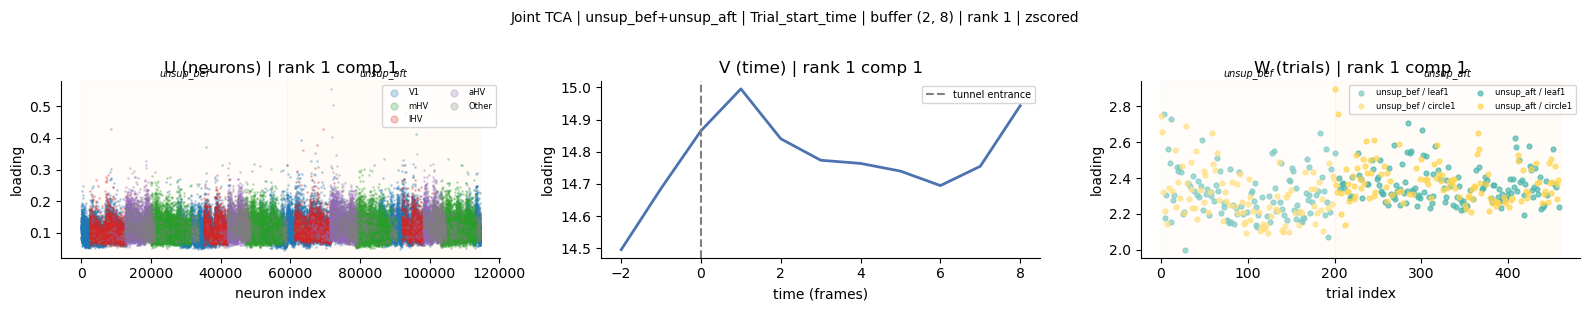

Saved: joint_tca_unsup_bef+unsup_aft_Trial_start_time_buf2-8_rank1_zscored.png


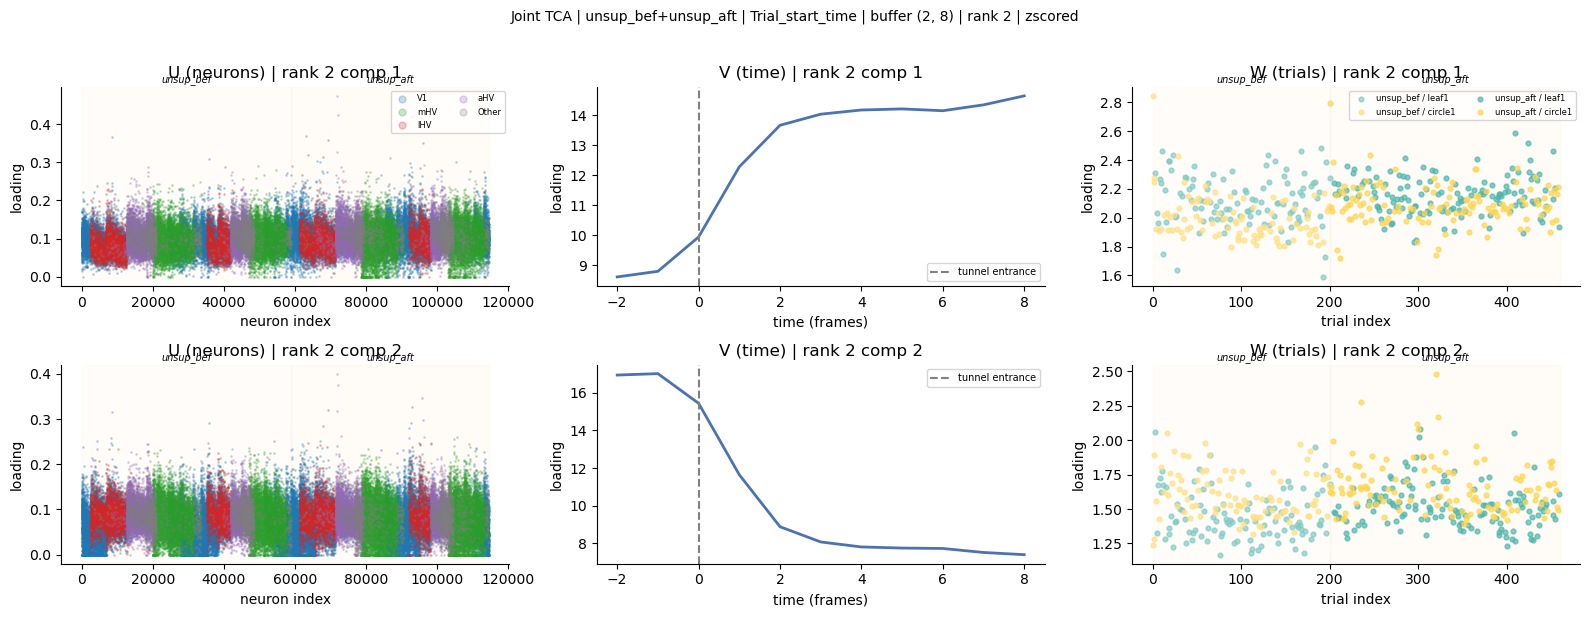

Saved: joint_tca_unsup_bef+unsup_aft_Trial_start_time_buf2-8_rank2_zscored.png


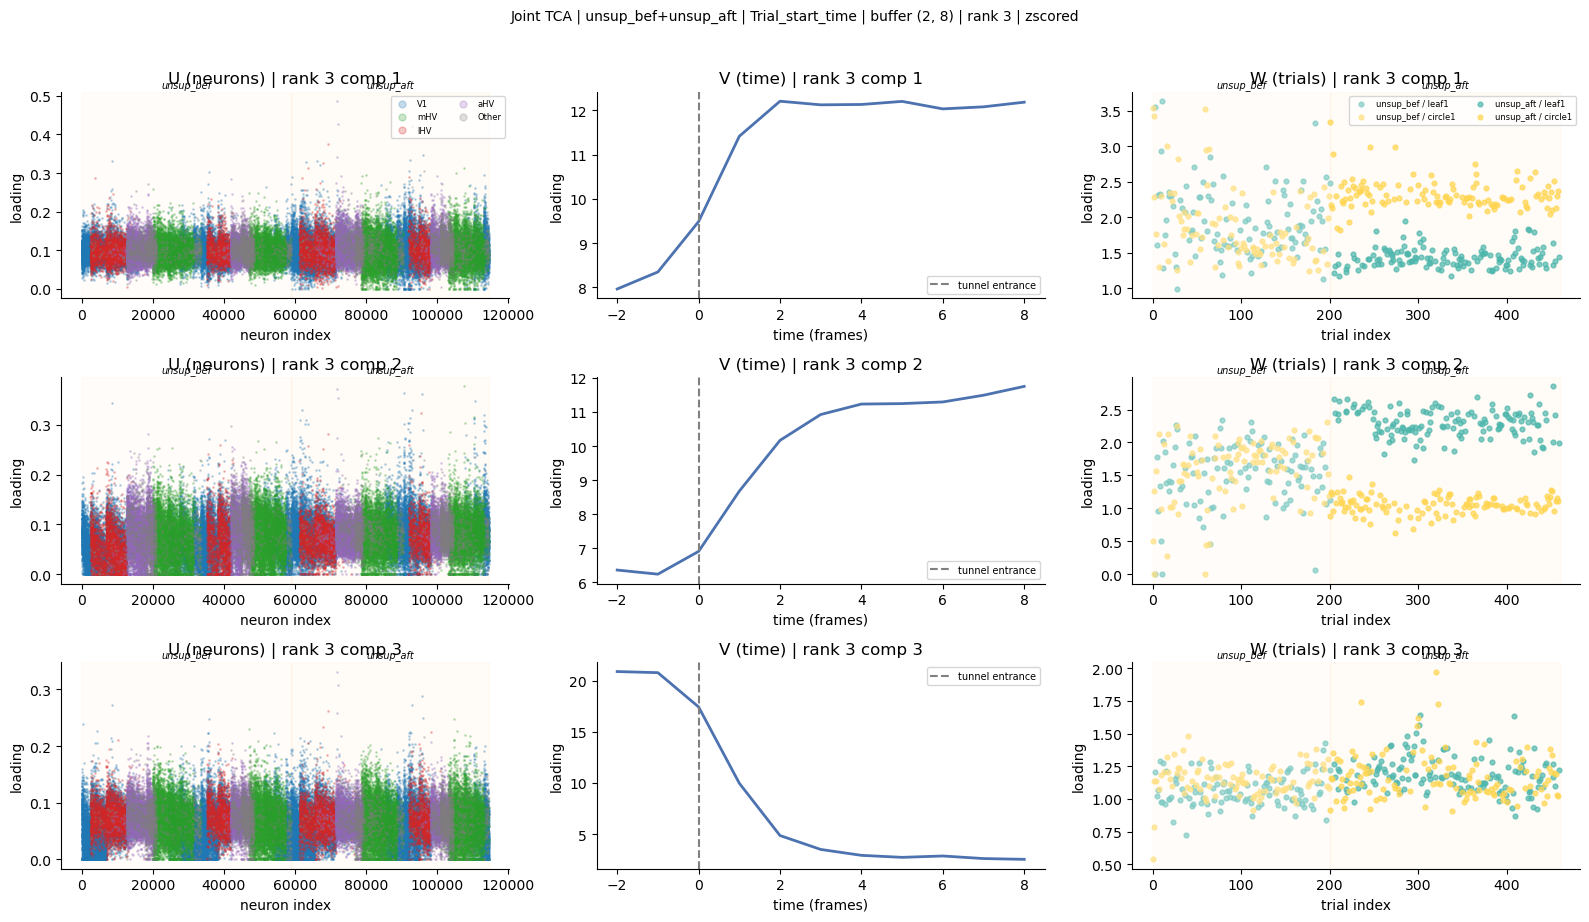

Saved: joint_tca_unsup_bef+unsup_aft_Trial_start_time_buf2-8_rank3_zscored.png


In [9]:
for r in RANK_RANGE:
    rep = best_rep_idx[r]
    facs = ensemble.factors(r)[rep]
    U, V, W = canonical_factors(*facs, N_total, n_time, K_total)
    nc = U.shape[1]

    fig, axes = plt.subplots(nc, 3, figsize=(16, 3 * max(nc, 1)), squeeze=False)

    for c in range(nc):
        # ── U (neurons) ──
        ax = axes[c, 0]
        for bi, sr in zip(block_info, session_results):
            n0, n1 = bi["neuron_slice"]
            ax.axvspan(n0, n1, alpha=0.07,
                       color=BLOCK_SHADE.get(sr["label"], "#eee"))
        for area, clr in AREA_PALETTE.items():
            sel = neuron_df.index[neuron_df["area"] == area]
            if len(sel) == 0:
                continue
            gidx = neuron_df.loc[sel, "global_idx"].values
            ax.scatter(gidx, U[gidx, c], s=1, c=clr, alpha=0.25,
                       label=area, rasterized=True)
        for bi, sr in zip(block_info, session_results):
            mid = sum(bi["neuron_slice"]) / 2
            ax.text(mid, 1.01, sr["label"],
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=7, fontstyle="italic")
        ax.set_xlabel("neuron index")
        ax.set_ylabel("loading")
        ax.set_title(f"U (neurons) | rank {r} comp {c + 1}")
        if c == 0:
            ax.legend(fontsize=6, ncol=2, loc="upper right", markerscale=5)
        sns.despine(ax=ax)

        # ── V (time, shared) ──
        ax = axes[c, 1]
        ax.plot(frame_order, V[:, c], lw=2,
                color=sns.color_palette("deep")[0])
        evt_label = ("tunnel entrance" if ALIGNMENT == "Trial_start_time"
                     else "sound cue")
        ax.axvline(0, color="gray", ls="--", lw=1.5, label=evt_label)
        ax.set_xlabel("time (frames)")
        ax.set_ylabel("loading")
        ax.set_title(f"V (time) | rank {r} comp {c + 1}")
        ax.legend(fontsize=7)
        ax.xaxis.set_major_locator(mpl_ticker.MaxNLocator(integer=True))
        sns.despine(ax=ax)

        # ── W (trials) ──
        ax = axes[c, 2]
        for bi, sr in zip(block_info, session_results):
            t0, t1 = bi["trial_slice"]
            ax.axvspan(t0, t1, alpha=0.07,
                       color=BLOCK_SHADE.get(sr["label"], "#eee"))
        for ss_key, clr in SESSION_STIM_PALETTE.items():
            sel = trial_df.index[trial_df["session_stim"] == ss_key]
            if len(sel) == 0:
                continue
            gidx = trial_df.loc[sel, "global_idx"].values
            ax.scatter(gidx, W[gidx, c], s=12, c=clr, alpha=0.7,
                       label=ss_key)
        for bi, sr in zip(block_info, session_results):
            mid = sum(bi["trial_slice"]) / 2
            ax.text(mid, 1.01, sr["label"],
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=7, fontstyle="italic")
        ax.set_xlabel("trial index")
        ax.set_ylabel("loading")
        ax.set_title(f"W (trials) | rank {r} comp {c + 1}")
        if c == 0:
            ax.legend(fontsize=6, ncol=2, loc="upper right")
        sns.despine(ax=ax)

    session_str = "+".join(s["label"] for s in session_results)
    fig.suptitle(
        f"Joint TCA | {session_str} | {ALIGNMENT} | "
        f"buffer {BUFFER_TUNNEL} | rank {r} | {TCA_INPUT}",
        fontsize=10, y=1.02)
    plt.tight_layout()
    fn = (f"joint_tca_{session_str}_{ALIGNMENT}_"
          f"buf{BUFFER_TUNNEL[0]}-{BUFFER_TUNNEL[1]}_rank{r}_{TCA_INPUT}.png")
    plt.savefig(results_dir / fn, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fn}")